# Lab 8: Image Segmentation with Watershed Algorithm in OpenCV
This lab focuses on applying the Watershed Algorithm for image segmentation using OpenCV. The exercises cover preprocessing an image, marking foreground and background, and applying the watershed algorithm to segment objects. Code is designed for a Jupyter Notebook, with images displayed inline using matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Exercise 1: Basic Watershed Segmentation
Task: Segment objects in an image using the Watershed Algorithm with manual markers.

(-0.5, 799.5, 449.5, -0.5)

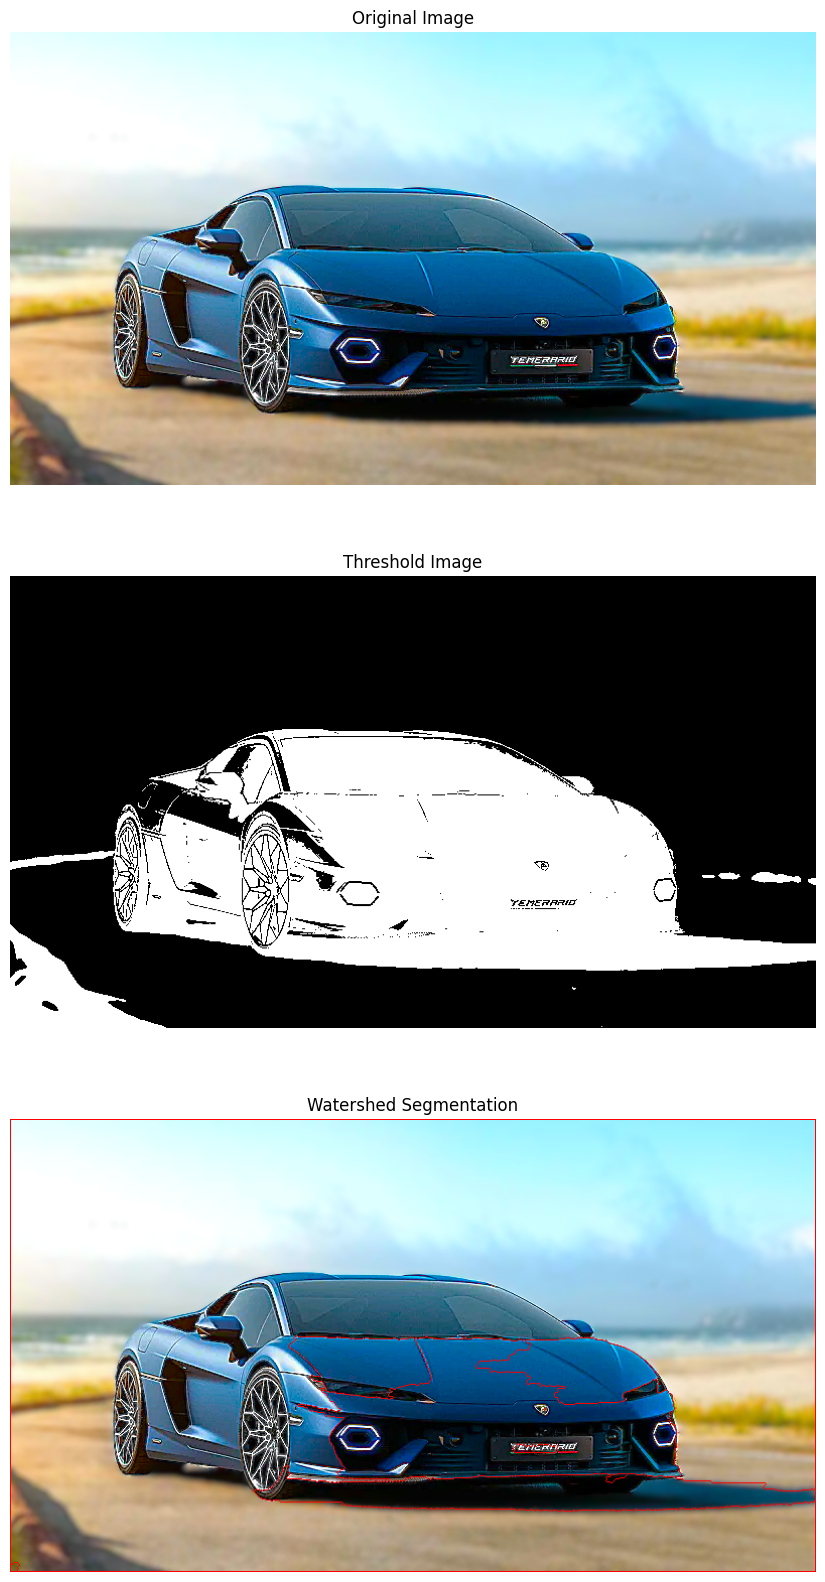

In [2]:
# Load image
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png')
if img is None:
    print("Error: Image not found.")
    exit()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
igg = img_rgb.copy()

# Convert to grayscale and threshold
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove noise with morphological opening
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Sure foreground with distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# Unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1  # Add 1 to avoid background as 0
markers[unknown == 255] = 0  # Mark unknown as 0

# Apply watershed
markers = cv2.watershed(img, markers)
img_rgb[markers == -1] = [255, 0, 0]  # Mark boundaries in red

# Display results
plt.figure(figsize=(20, 20))

plt.subplot(3, 1, 1)
plt.title('Original Image')
plt.imshow(igg)
plt.axis('off')

plt.subplot(3, 1, 2)
plt.title('Threshold Image')
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(3,1, 3)
plt.title('Watershed Segmentation')
plt.imshow(img_rgb)
plt.axis('off')

## Exercise 2: Interactive Marker-Based Watershed
Task: Create markers manually for specific objects (e.g., car body) and apply watershed segmentation.

(-0.5, 799.5, 449.5, -0.5)

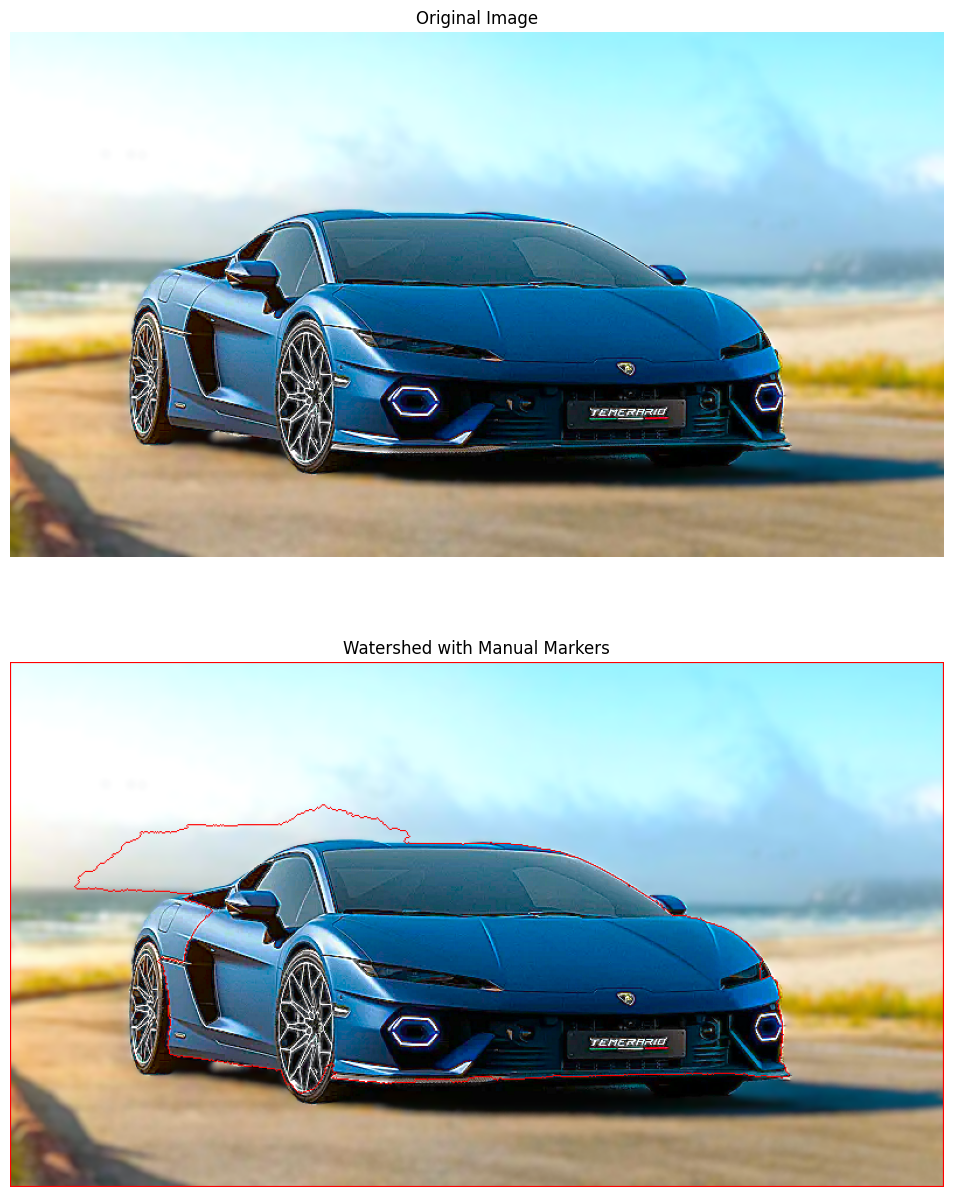

In [3]:
# Load image
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png')
if img is None:
    print("Error: Image not found.")
    exit()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
i_show = img_rgb.copy()

# Create a blank marker image
markers = np.zeros((img.shape[0], img.shape[1]), dtype=np.int32)

# Manually set markers (example coordinates for car body and background)
# Adjust based on your image
markers[150:250, 200:300] = 1  # Car body
markers[0:50, 0:50] = 2       # Background

# Apply watershed
markers = cv2.watershed(img, markers)
img_rgb[markers == -1] = [255, 0, 0]  # Mark boundaries in red

# Display results
plt.figure(figsize=(20, 15))

plt.subplot(2, 1, 1)
plt.title('Original Image')
plt.imshow(i_show)
plt.axis('off')

plt.subplot(2,1, 2)
plt.title('Watershed with Manual Markers')
plt.imshow(img_rgb)
plt.axis('off')

## Exercise 3: Watershed with Preprocessing and Contour Overlay
Task: Combine preprocessing, watershed segmentation, and contour overlay to highlight segmented regions.

(-0.5, 799.5, 449.5, -0.5)

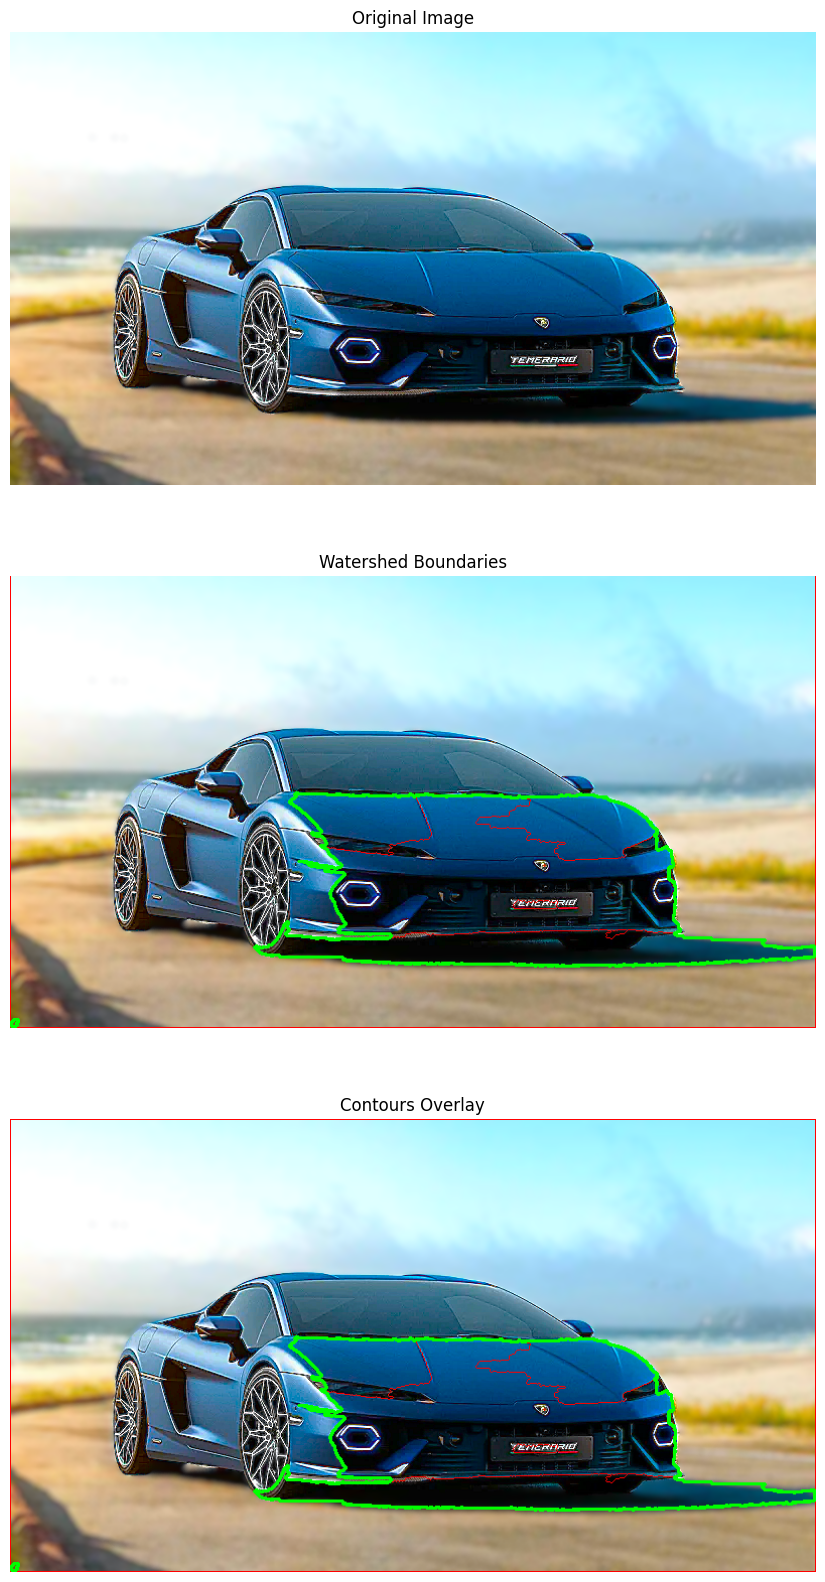

In [4]:
# Load image
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png')
if img is None:
    print("Error: Image not found.")
    exit()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
igg = img_rgb.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply thresholding and morphological operations
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Sure background and foreground
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(img, markers)
img_rgb[markers == -1] = [255, 0, 0]  # Boundaries in red

# Find and draw contours of segmented regions
contours, _ = cv2.findContours((markers > 1).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(img_rgb, contours, -1, (0, 255, 0),2)

# Display results
plt.figure(figsize=(15, 20))

plt.subplot(3, 1, 1)
plt.title('Original Image')
plt.imshow(igg)
plt.axis('off')

plt.subplot(3, 1, 2)
plt.title('Watershed Boundaries')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(3, 1, 3)
plt.title('Contours Overlay')
plt.imshow(img_rgb)
plt.axis('off')

# By **Saddam Umer**

BS AI, SMIU